In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'
TEST_YEAR = '2022'
TEST_MONTH = '8'
NUTS2_EL = 'θρακης'

In [3]:
trained_model = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [4]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(840, 112)


In [5]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL511,2010,1,26.176106,41.222160,0.212907,0.037536,-0.140197,-0.037536,0.201926,0.032885,-0.136198,-0.032885,0.036767,0.041530,0.058430,0.041530,10.257397,5.319432,9.448205,14.314735,14.314735,4.733490,-0.739066,2.375193,0.624374,0.624374,7.495444,2.290183,5.911699,7.469555,7.469555,1.815500,14.229300,11.651058,77.314115,176.318629,359.651239,1692.476395,36.348039,1.172517,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,1428.0,1397.0,0
1,EL512,2010,1,24.892059,41.169359,0.301065,-0.016614,-0.299816,0.016614,0.287990,-0.020438,-0.288824,0.020438,0.046475,0.052463,0.075413,0.052463,12.922081,6.769895,8.424589,14.517815,14.517815,4.707540,-0.479640,1.864893,1.117661,1.117661,8.814810,3.145128,5.144741,7.817738,7.817738,3.180500,14.693500,9.796280,44.175999,88.094992,301.865542,1706.160895,31.000000,1.000000,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,1495.0,1597.0,0
2,EL513,2010,1,25.520366,41.111582,0.168641,-0.002557,-0.144486,0.002557,0.161442,0.001173,-0.136416,-0.001173,0.039250,0.042357,0.065412,0.042357,11.885453,7.231715,8.701025,14.774006,14.774006,4.907539,0.014150,2.438802,1.236478,1.236478,8.396496,3.622932,5.569914,8.005242,8.005242,4.038065,15.627742,10.958125,23.452482,92.947734,337.903445,1655.149838,31.000000,1.000000,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,31,36,30,12,12,3,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.49

In [6]:
data_test = data_test[data_test['year'] == 2022]
data_test.reset_index(drop=True, inplace=True)
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL511,2022,1,26.176106,41.222160,0.256957,0.086450,-0.197882,-0.086450,0.202165,0.149887,-0.150557,-0.149961,0.042210,0.048576,0.045191,0.048613,9.816371,9.132452,12.484621,16.325590,16.325590,3.315548,2.226110,2.919818,2.146052,2.146052,6.565960,5.679281,7.702220,9.235821,9.235821,-4.266000,13.990000,9.175011,129.395180,130.000556,284.402694,2100.191519,42.485294,1.370493,15.416667,21.000000,46.666667,845.800679,39.0,-6.0,45.0,5.500000,26.166667,26.166667,5.500000,2094.0,546.0,30.0,82.527790,1075.0,103.0,103.0,1075.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,9769.0,48015.0,16945.0,74729.0,8618.0,42969.0,20266.0,71853.0,1714.79,3612.0,4034.0,0
1,EL512,2022,1,24.892059,41.169359,0.296964,-0.003927,-0.276683,0.003927,0.279013,0.003389,-0.255548,-0.003389,0.054807,0.062999,0.064970,0.062999,7.592516,7.680476,10.981545,15.129790,15.129790,1.413774,1.425694,2.728848,1.631395,1.631395,4.503145,4.553085,6.855196,8.380593,8.380593,-3.401750,12.797250,10.368162,24.134803,24.463903,321.408624,1952.184197,31.000000,1.000000,14.416667,20.500000,48.809524,806.178791,37.0,-5.0,42.0,4.833333,24.166667,24.333333,4.833333,1947.0,417.0,46.0,78.030175,886.0,180.0,270.0,886.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,9120.0,37607.0,9039.0,55766.0,8435.0,35750.0,10917.0,55102.0,993.81,2048.0,2252.0,0
2,EL513,2022,1,25.520366,41.111582,0.288559,0.065072,-0.247112,-0.065072,0.253539,0.113674,-0.213128,-0.113674,0.057611,0.061900,0.062919,0.061900,8.008460,8.712112,11.592177,16.331649,16.331649,2.890031,2.552045,3.120829,2.012908,2.012908,5.449246,5.632079,7.356503,9.172279,9.172279,-3.021774,12.027419,9.767160,110.913478,111.601377,302.781662,2147.172147,31.000000,1.000000,15.750000,21.166667,47.037037,886.643313,40.0,-5.0,45.0,5.500000,26.666667,26.833333,5.500000,2140.0,523.0,30.0,83.407689,1058.0,120.0,203.0,1058.0,31,20,30,12,9,4,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,

In [7]:
data_test = encode_cyclical(data_test, 'month', 12)

In [8]:
len(data_test.NUTS3_ID.unique())

5

In [9]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [10]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL511,2022,8,26.176106,41.222160,0.507110,0.116307,-0.461209,-0.116307,0.507587,0.120308,-0.460216,-0.120308,0.066679,0.062510,0.043514,0.062510,33.557352,7.197848,11.949104,12.243442,12.243442,19.509871,1.085684,1.556164,-0.683271,-0.683271,26.533611,4.141766,6.752634,5.780085,5.780085,16.726200,38.005300,1.384492,8.177039,8.193355,42.919245,756.471591,1446.985294,46.676945,15.416667,21.000000,46.666667,845.800679,39.0,-6.0,45.0,5.500000,26.166667,26.166667,5.500000,2094.0,546.0,30.0,82.527790,1075.0,103.0,103.0,1075.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,9769.0,48015.0,16945.0,74729.0,8618.0,42969.0,20266.0,71853.0,1714.79,3612.0,4034.0,0,-0.866025,-0.5
1,EL512,2022,8,24.892059,41.169359,0.625528,0.193740,-0.546446,-0.193740,0.616296,0.186566,-0.540437,-0.186566,0.058638,0.058951,0.039430,0.058951,30.402927,6.552524,11.074036,12.536202,12.536202,19.938040,-0.480016,1.251277,-0.226823,-0.226823,25.170484,3.036254,6.162656,6.154690,6.154690,16.754250,34.075250,2.572456,39.477544,39.477544,79.629620,933.906523,1085.887500,35.028629,14.416667,20.500000,48.809524,806.178791,37.0,-5.0,42.0,4.833333,24.166667,24.333333,4.833333,1947.0,417.0,46.0,78.030175,886.0,180.0,270.0,886.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,9120.0,37607.0,9039.0,55766.0,8435.0,35750.0,10917.0,55102.0,993.81,2048.0,2252.0,0,-0.866025,-0.5
2,EL513,2022,8,25.520366,41.111582,0.489618,0.098068,-0.457872,-0.098068,0.489787,0.098768,-0.456029,-0.098768,0.064742,0.062761,0.043513,0.062761,34.981582,7.175911,11.822177,12.642060,12.642060,20.898325,0.273522,1.453399,-0.108606,-0.108606,27.939953,3.724716,6.637788,6.266727,6.266727,18.604839,39.015000,1.180137,25.739528,25.740242,36.584245,783.815075,1366.161290,44.069719,15.750000,21.166667,47.037037,886.643313,40.0,-5.0,45.0,5.500000,26.666667,26.833333,5.500000,2140.0,523.0,30.0,83.407689,1058.0,120.0,203.0,1058.0,31,20,30,12,9,4,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017

In [11]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [12]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [13]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [14]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
4,EL515,2022,8,24.438568,40.915602,0.569210
2,EL513,2022,8,25.520366,41.111582,0.353201
0,EL511,2022,8,26.176106,41.222160,0.352277
3,EL514,2022,8,24.180725,41.300798,0.256424
1,EL512,2022,8,24.892059,41.169359,0.177856


In [15]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [16]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [17]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL51,"Aνατολική Μακεδονία, Θράκη","MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [18]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL511,Έβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,Ξάνθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,Ροδόπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,Δράμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,"Θάσος, Καβάλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [19]:
greece_lau1.head()

,NAME,geometry
0,Ορεστιάδας,"POLYGON ((26.24076 41.73167, 26.24274 41.73022..."
1,Σουφλίου,"POLYGON ((26.17788 41.37548, 26.17812 41.37442..."
2,Αβδήρων,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
3,Αλεξανδρούπολης,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
4,Αρριανών,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."


In [20]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,ISMARIDA LAKE,1865103.9,5520.085,"POLYGON ((25.30862 40.99215, 25.30977 40.99238...",0
1,LEFKOGION RESERVOIR,1091876.6,11878.964,"POLYGON ((23.90767 41.40275, 23.90769 41.40308...",1
2,PLATANOBRISI RESERVOIR,3250727.5,40050.050,"POLYGON ((24.37308 41.36354, 24.37362 41.36409...",2
3,THISAVROS RESERVOIR,6928690.5,34912.035,"POLYGON ((24.28272 41.31770, 24.28317 41.31766...",3
4,GRATINI RESERVOIR,1434043.4,12178.949,"POLYGON ((25.51603 41.16096, 25.51670 41.16102...",4


In [21]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [22]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [23]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL511,2022,8,26.1761,41.2222,0.352277,Έβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,2022,8,24.8921,41.1694,0.177856,Ξάνθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,2022,8,25.5204,41.1116,0.353201,Ροδόπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,2022,8,24.1807,41.3008,0.256424,Δράμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,2022,8,24.4386,40.9156,0.569210,"Θάσος, Καβάλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [24]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

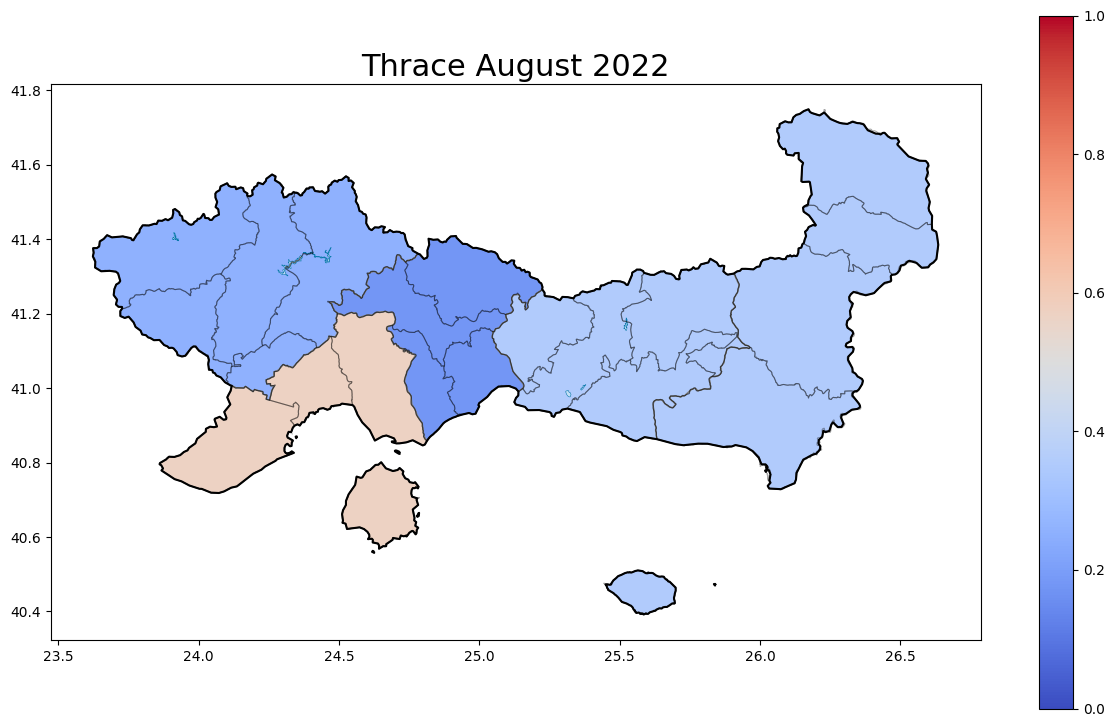

In [25]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [26]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = f'[EL51]East Macedonia & Thrace - August 2022',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=650, fig_width=1000, size_f5=6.5)

fig.show()

In [27]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL511,2022,8,26.1761,41.2222,0.352277,Έβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,2022,8,24.8921,41.1694,0.177856,Ξάνθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,2022,8,25.5204,41.1116,0.353201,Ροδόπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,2022,8,24.1807,41.3008,0.256424,Δράμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,2022,8,24.4386,40.9156,0.569210,"Θάσος, Καβάλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [28]:
results[['NUTS3_ID', 'NUTS3_NAME', 'year', 'month', 'risk_score']]

,NUTS3_ID,NUTS3_NAME,year,month,risk_score
0,EL511,Έβρος,2022,8,0.352277
1,EL512,Ξάνθη,2022,8,0.177856
2,EL513,Ροδόπη,2022,8,0.353201
3,EL514,Δράμα,2022,8,0.256424
4,EL515,"Θάσος, Καβάλα",2022,8,0.569210


In [29]:
#